<a href="https://colab.research.google.com/github/KULDEEPSONI-source/TIMESERIES-ANALYSIS-FORCASTING/blob/main/facebook_prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# pip install pystan

In [25]:
# pip install prophet

In [26]:
from prophet import Prophet
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

In [27]:
df = pd.read_csv('/content/AirPassengers.csv')
df.head(5)
df = df.rename(columns={'#Passengers': 'y', 'Month':'ds'})

In [28]:
df.tail(5)

,ds,y
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [29]:
df['y_orig'] = df['y']
print(df.head(5))

        ds    y  y_orig
0  1949-01  112     112
1  1949-02  118     118
2  1949-03  132     132
3  1949-04  129     129
4  1949-05  121     121


In [30]:
df['y']= np.log(df['y'])

In [31]:
df.head(5)

,ds,y,y_orig
0,1949-01,4.718499,112
1,1949-02,4.770685,118
2,1949-03,4.882802,132
3,1949-04,4.859812,129
4,1949-05,4.795791,121


This code snippet demonstrates the fundamental workflow for using Facebook's **Prophet** library to forecast time-series data while accounting for holidays.

Here is the step-by-step breakdown of the code provided:

### 1. Instantiate the Model

```python
model = Prophet()

```

* **Purpose:** This creates an instance of the Prophet forecasting model.
* **Details:** By default, `Prophet()` sets up a Bayesian additive model. When you initialize it without arguments, it uses default settings for seasonality (yearly, weekly, daily) and growth models.

### 2. Incorporate Holiday Effects

```python
model.add_country_holidays(country_name='US')

```

* **Purpose:** This tells the model to automatically account for holidays specific to the United States.
* **Details:** Prophet maintains a built-in list of major holidays for many countries. When you call this, the model adds extra regressors for each holiday, allowing it to estimate the specific impact (the "holiday effect") those days have on your target variable.

### 3. Fit the Model

```python
model.fit(df)

```

* **Purpose:** This is the training phase.
* **Details:** Prophet processes your `df` (which must be a Pandas DataFrame).
* **Requirements:** The DataFrame **must** have exactly two columns:
* `ds`: Datetime strings or objects.
* `y`: Numeric values representing the metric you want to forecast.


* **Internal Process:** During this step, the model fits the growth trend, seasonality components, and holiday effects using the data provided.



---

### Implementation: Train-Test Split Workflow

To follow your request to evaluate model performance, you should split your data chronologically (time-series data cannot be shuffled like standard machine learning data).

#### Example Workflow

```python
# 1. Split the data chronologically
split_date = '2025-12-31' # Example date
train = df[df['ds'] <= split_date]
test = df[df['ds'] > split_date]

# 2. Fit on training data
model = Prophet()
model.add_country_holidays(country_name='US')
model.fit(train)

# 3. Create a forecast for the test period
# You must create a dataframe of dates to predict
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

# 4. Compare
# 'forecast' contains 'yhat' (the prediction).
# Slice it to match the 'test' dates and compare.

```

Would you like to explore how to calculate specific error metrics like Mean Absolute Percentage Error (MAPE) to quantify how well the model performed against your test data?

In [32]:
model = Prophet() #instantiate Prophet
model.add_country_holidays(country_name='US')
model.fit(df)

#train_test_split: df: train/test, then run the code for train, compare the prediction vs test

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [33]:
'''     'year': 'A',
        'quarter': 'Q',
        'month': 'M',
        'day': 'D',
        'hour': 'H',
        'minute': 'T',
        'second': 'S',
        'millisecond': 'L',
        'microsecond': 'U',
        'nanosecond': 'N'}
'''
#future_data = model.make_future_dataframe(periods=6, freq = 'H')
future_data = model.make_future_dataframe(periods=12, freq = 'M')

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [34]:
forecast_data = model.predict(future_data)

In [35]:
forecast_data.tail(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Armistice Day,Armistice Day_lower,Armistice Day_upper,Christmas Day,...,holidays,holidays_lower,holidays_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
151,1961-07-31,6.276164,6.436064,6.528047,6.263649,6.287564,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.209160,0.209160,0.209160,0.0,0.0,0.0,6.485324
152,1961-08-31,6.285259,6.318464,6.414152,6.270690,6.299234,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.077256,0.077256,0.077256,0.0,0.0,0.0,6.362514
153,1961-09-30,6.294060,6.156538,6.254290,6.275993,6.310837,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.087041,-0.087041,-0.087041,0.0,0.0,0.0,6.207019
154,1961-10-31,6.303155,6.019429,6.119163,6.282035,6.323669,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.230903,-0.230903,-0.230903,0.0,0.0,0.0,6.072252
155,1961-11-30,6.311956,6.159205,6.265882,6.287702,6.335039,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.099315,-0.099315,-0.099315,0.0,0.0,0.0,6.212641


In [36]:
forecast_data[['ds','yhat','yhat_lower','yhat_upper']].tail(5)

,ds,yhat,yhat_lower,yhat_upper
151,1961-07-31,6.485324,6.436064,6.528047
152,1961-08-31,6.362514,6.318464,6.414152
153,1961-09-30,6.207019,6.156538,6.254290
154,1961-10-31,6.072252,6.019429,6.119163
155,1961-11-30,6.212641,6.159205,6.265882


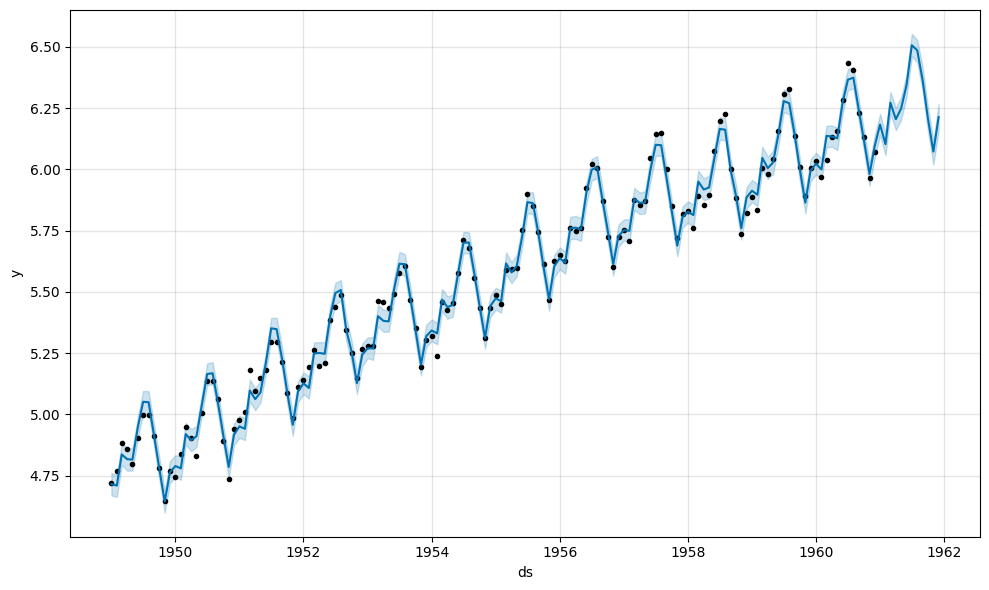

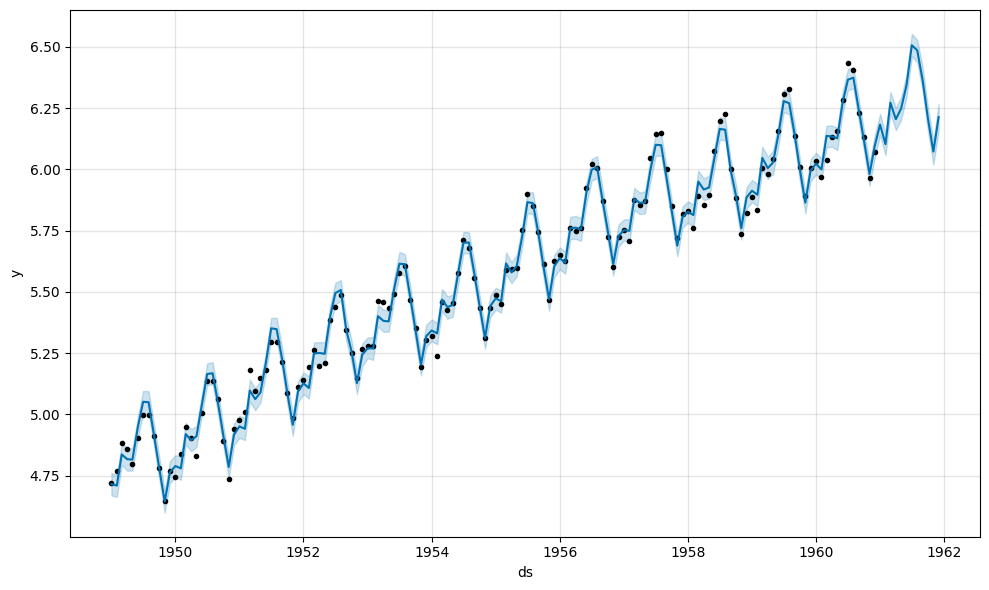

In [37]:
model.plot(forecast_data)

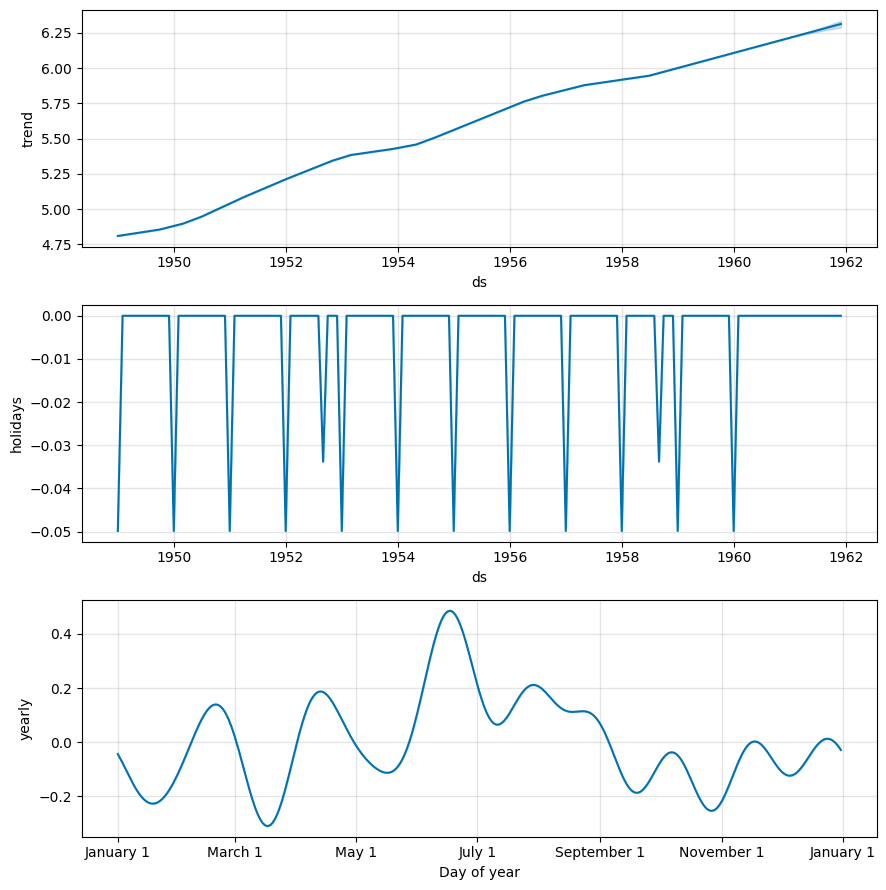

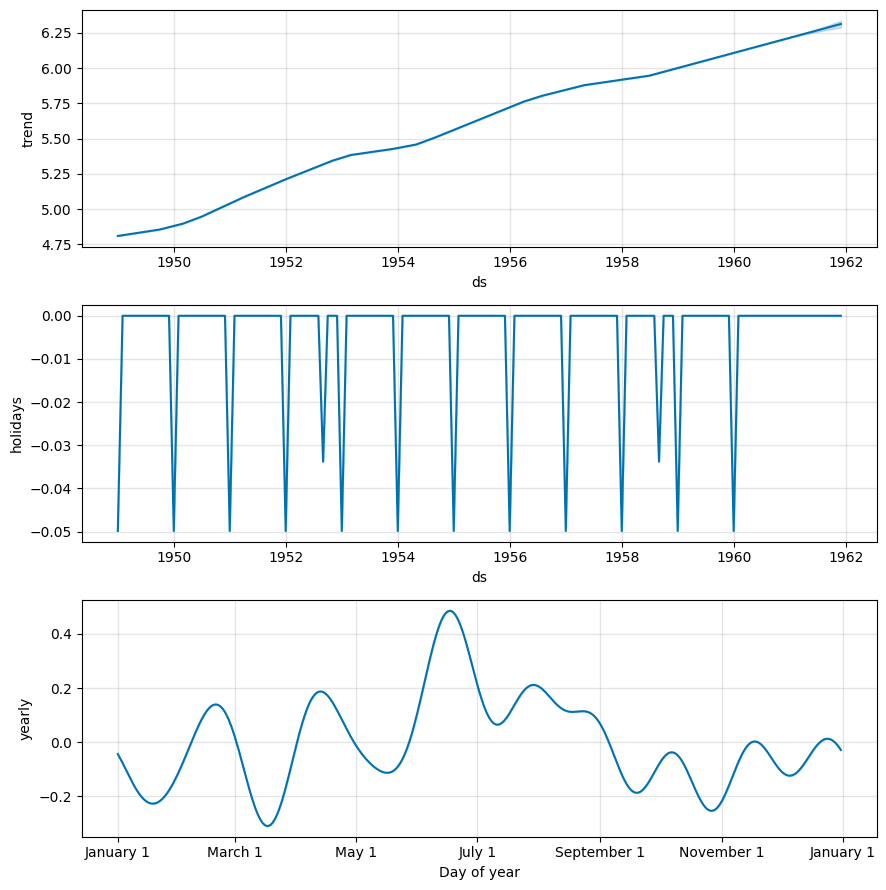

In [38]:
model.plot_components(forecast_data)

In [39]:
forecast_data_orig = forecast_data # make sure we save the original forecast data
forecast_data_orig['yhat'] = np.exp(forecast_data_orig['yhat'])
forecast_data_orig['yhat_lower'] = np.exp(forecast_data_orig['yhat_lower'])
forecast_data_orig['yhat_upper'] = np.exp(forecast_data_orig['yhat_upper'])

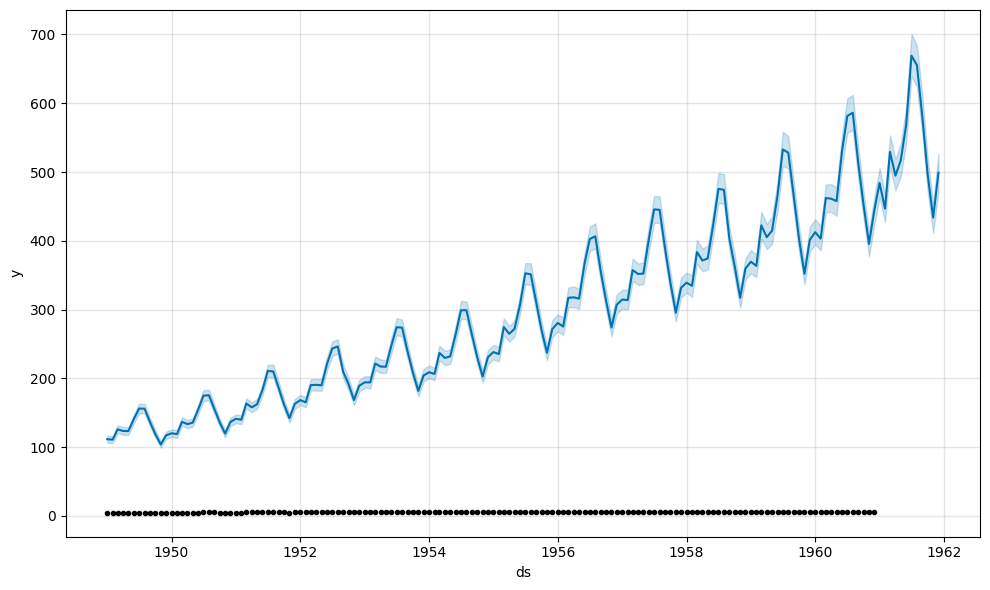

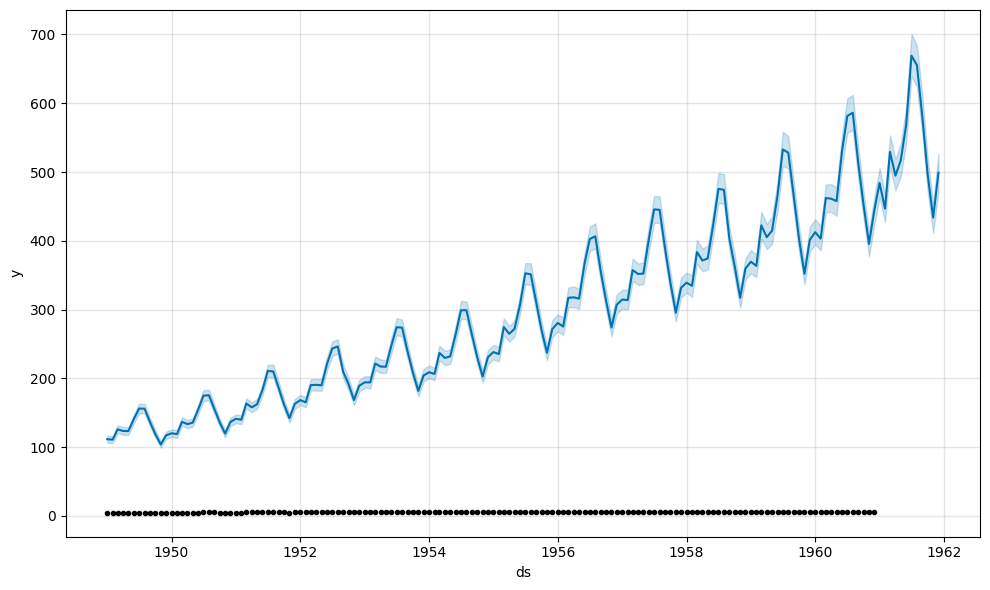

In [40]:
model.plot(forecast_data_orig)

In [41]:
df['y_log']=df['y'] #copy the log-transformed data to another column
df['y']=df['y_orig']

In [42]:
final_df = pd.DataFrame(forecast_data_orig)

In [43]:
import plotly.graph_objs as go
import plotly.offline as py

In [44]:
#Plot predicted and actual line graph with X=dates, Y=Outbound
actual_chart = go.Scatter(y=df["y_orig"], name= 'Actual')
predict_chart = go.Scatter(y=final_df["yhat"], name= 'Predicted')
predict_chart_upper = go.Scatter(y=final_df["yhat_upper"], name= 'Predicted Upper')
predict_chart_lower = go.Scatter(y=final_df["yhat_lower"], name= 'Predicted Lower')
py.plot([actual_chart, predict_chart, predict_chart_upper, predict_chart_lower], image_width=400, image_height=400)
#py.plot([actual_chart, predict_chart, predict_chart_upper, predict_chart_lower], filename = 'templates/' +'filename.html', auto_open=False)

'temp-plot.html'

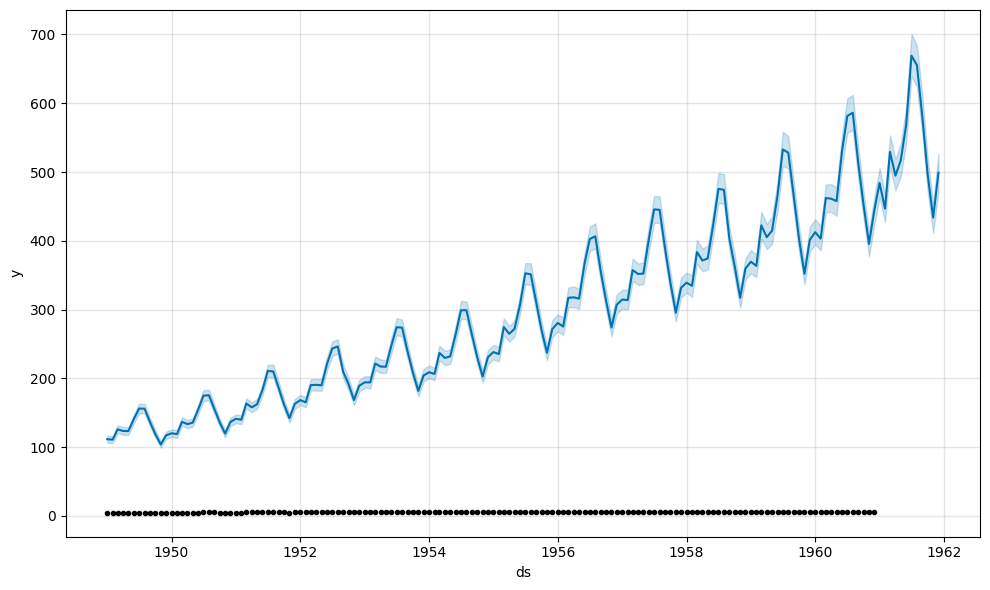

In [45]:
fig = model.plot(forecast_data)
fig.savefig('forecast.png')